In [20]:
import os
import fnmatch
import pandas as pd
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [21]:
# This is my local dir. change to yours :)
dir_path = '/Users/khangdao/Desktop/Project DS/Random_series'

# List all folders in the directory
path_list = [f.path for f in os.scandir(dir_path) if f.is_dir()]

# Print the list of folders
# print(path_list)

images = []
for path in path_list:
    # path = './Random_series_001'
    data = pd.read_csv(f'{path}/image_data.csv')
    df = pd.DataFrame(data)
    boundary = pd.DataFrame()
    df = df.drop(['BaS', 'Sn2BaS3', 'SnS', 'BaS_thickness_cm', 'Sn2BaS3_thickness_cm', 'SnS_thickness_cm'], axis=1)

    # Find the .tif file named Filtered_R_Image in the same directory
    for file in os.listdir(path):
        if file == "Filtered_t_Image.tif":
            # Open the .tif file
            image = Image.open(os.path.join(path, file))
            # Append the image to the images list
            images.append(image)

    with open(f'{path}/settings.json', 'r') as f:
        settings = json.load(f)
    
    boundary1 = settings['boundaries'][1]
    boundary2 = settings['boundaries'][2]
    if 'boundaries' in settings and len(settings['boundaries']) > 2:
        boundary = pd.DataFrame({
        'boundary1': [boundary1],
        'boundary2': [boundary2]
    })
    else:
        raise ValueError("Settings do not contain valid boundaries.")
    df['target'] = df['F'].apply(lambda x: 1 if x < boundary1 else 2 if boundary1 <= x <= boundary2 else 3)

    boundary.to_csv(f'{path}/boundary.csv', index=False)
    df.to_csv(f'{path}/image_data_1.csv', index=False)

print(df.head())
print(settings['boundaries'])

##########################################
# TRAIN - VAL - TEST (Local setup)
##########################################

# path_list = []
# for root, dirs, files in os.walk('./'):
#     # print(root)
#     if len(root)>2:
#         path_list.append(root)

train_directories = path_list[:100]
val_directories = path_list[100:150]
test_directories = path_list[150:]

print(train_directories)
print(val_directories)
print(test_directories)

      x     y            Sn            Ba         F  target
0 -2.49 -0.49  4.323034e-07  2.444360e-07  0.638803       1
1 -2.49 -0.44  4.309572e-07  2.435826e-07  0.638891       1
2 -2.49 -0.39  4.296010e-07  2.427209e-07  0.638981       1
3 -2.49 -0.34  4.282348e-07  2.418509e-07  0.639075       1
4 -2.49 -0.29  4.268590e-07  2.409730e-07  0.639171       1
[0, 0.64, 0.76, 1]
['/Users/khangdao/Desktop/Project DS/Random_series/Random_series_041', '/Users/khangdao/Desktop/Project DS/Random_series/Random_series_079', '/Users/khangdao/Desktop/Project DS/Random_series/Random_series_046', '/Users/khangdao/Desktop/Project DS/Random_series/Random_series_070', '/Users/khangdao/Desktop/Project DS/Random_series/Random_series_084', '/Users/khangdao/Desktop/Project DS/Random_series/Random_series_048', '/Users/khangdao/Desktop/Project DS/Random_series/Random_series_083', '/Users/khangdao/Desktop/Project DS/Random_series/Random_series_077', '/Users/khangdao/Desktop/Project DS/Random_series/Random_ser

In [22]:
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance



def enhance_contrast_and_brightness(img, contrast_factor=2.0, brightness_factor=2.5):
    brightness_enhancer = ImageEnhance.Brightness(img)
    brightened_img = brightness_enhancer.enhance(brightness_factor)

    contrast_enhancer = ImageEnhance.Contrast(brightened_img)
    enhanced_img = contrast_enhancer.enhance(contrast_factor)

    return enhanced_img

def combine_data_and_images(directories, data_type):
    # Parameters to crop image
    left =  135
    upper = 13
    right = 740
    lower = 618
    crop_box = (left, upper, right, lower)


    combined_data = pd.DataFrame()
    df_list = []
    images = []  # Initialize an empty list to store the images
    enhanced_image = []
    boundary_list = []

    for directory in directories:
        # Construct paths for CSV and image files
        file_path = os.path.join(directory, 'image_data_1.csv')
        image_path = os.path.join(directory, 'Filtered_T_Image.tif')
        boundary_path = os.path.join(directory, 'boundary.csv')

        # Check if the CSV file exists
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            df_list.append(df)
            combined_data = pd.concat([combined_data, df], ignore_index=True)
        else:
            print(f"File not found: {file_path}")

        # Check if the image file exists
        if os.path.exists(image_path):
            img = Image.open(image_path).crop(crop_box)
            enhanced_img = enhance_contrast_and_brightness(img)
            images.append(img)
            enhanced_image.append(enhanced_img)
        else:
            print(f"Image not found: {image_path}")

        # Check if the boundary CSV file exists
        if os.path.exists(boundary_path):
            boundary = pd.read_csv(boundary_path)
            boundary_list.append(boundary.values.flatten())
        else:
            print(f"File not found: {boundary_path}")

    # Save the combined DataFrame to a CSV file
    output_csv = f'{data_type}_data.csv'
    combined_data.to_csv(output_csv, index=False)
    print(f"Data combined successfully into '{output_csv}'.")

    return images, enhanced_image, df_list, boundary_list

train_images_list, train_enhanced_images_list, train_df_list, train_boundary_list = combine_data_and_images(train_directories, 'train')
val_images_list, val_enhanced_images_list, val_df_list, val_boundary_list = combine_data_and_images(val_directories, 'val')
test_images_list, test_enhanced_images_list, test_df_list, test_boundary_list = combine_data_and_images(test_directories, 'test')

Data combined successfully into 'train_data.csv'.
Data combined successfully into 'val_data.csv'.
Data combined successfully into 'test_data.csv'.


In [23]:
def plot_targets_on_simulated_image(df):
    # Determine the range of coordinates
    x_min, x_max = df['x'].min(), df['x'].max()
    y_min, y_max = df['y'].min(), df['y'].max()
    # print(x_min, x_max, y_min, y_max)
    
    # Create a blank white image based on the coordinate range
    img_width = int(x_max - x_min)
    img_height = int(y_max - y_min)
    img = Image.new('RGB', (img_width, img_height), 'white')
    # Create a figure and axis
    fig, ax = plt.subplots()

    # Display the blank image
    ax.imshow(img, extent=[x_min, x_max, y_min, y_max], aspect='equal')

    # Plot points based on target values
    colors = {1: 'lightblue', 2: 'plum', 3: 'tomato'}
    
    # Plot each unique coordinate for each target
    for target in colors.keys():
        target_points = df[df['target'] == target]
        
        # Use the coordinates to plot the points on the image
        ax.scatter(target_points['x'], target_points['y'], 
                   color=colors[target], 
                   label=f'Target {target}', 
                   s=10,
                   alpha=0.5)

    # Set the axis limits to match the coordinate range
    ax.set_xlim([x_min, x_max])
    ax.set_ylim([y_min, y_max])

    # Encode the target labels
    le = LabelEncoder()
    df['target_encoded'] = le.fit_transform(df['target'])

    # Fit logistic regression model
    X = df[['x', 'y']]
    y = df['target_encoded']
    model = LogisticRegression(multi_class='multinomial')
    model.fit(X, y)
    
    # Create a mesh to plot the decision boundaries
    xx, yy = np.meshgrid(np.linspace(x_min - 1, x_max + 1, 100), np.linspace(y_min - 1, y_max + 1, 100))
    
    # Ensure xx and yy are DataFrames with the appropriate column names
    grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=['x', 'y'])
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)

    # Plot decision boundaries
    ax.contour(xx, yy, Z, levels=[0.5, 1.5], colors=['darkgreen', 'darkgreen'], linestyles=['-', '-'])

    # Add labels and legend
    ax.set_title('"True" Decision Boundaries')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    # Show the plot
    plt.show()


def plot_targets_on_real_image(df, img):

    img_width, img_height = img.size

    # Create a figure and axis
    fig, ax = plt.subplots()

    # Display the image
    ax.imshow(img, extent=[df['x'].min(), df['x'].max(), df['y'].min(), df['y'].max()])
    


    # Plot points based on target values
    colors = {1: 'lightblue', 2: 'plum', 3: 'tomato'}
    
    # Plot each unique coordinate for each target
    for target in colors.keys():
        target_points = df[df['target'] == target]
        
        # Use the coordinates to plot the points on the image
        ax.scatter(target_points['x'], target_points['y'], 
                   color=colors[target], 
                   label=f'Target {target}', 
                   s=10,
                   alpha = 0)

    # Set the axis limits to match the coordinate range
    ax.set_xlim([df['x'].min(), df['x'].max()])
    ax.set_ylim([df['y'].min(), df['y'].max()])

    # Encode the target labels
    le = LabelEncoder()
    df['target_encoded'] = le.fit_transform(df['target'])

    # Fit logistic regression model
    X = df[['x', 'y']]
    y = df['target_encoded']
    model = LogisticRegression(multi_class='multinomial')
    model.fit(X, y)
    
    # Create a mesh to plot the decision boundaries
    x_min, x_max = df['x'].min() - 1, df['x'].max() + 1
    y_min, y_max = df['y'].min() - 1, df['y'].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    # Ensure xx and yy are DataFrames with the appropriate column names
    grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=['x', 'y'])
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)

    # Plot decision boundaries
    ax.contour(xx, yy, Z, levels=[0.5, 1.5], colors=['darkgreen', 'darkgreen'], linestyles=['-', '-'])

    # Add labels and legend
    ax.set_title('True Decision Boundaries')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    # Show the plot
    plt.show()


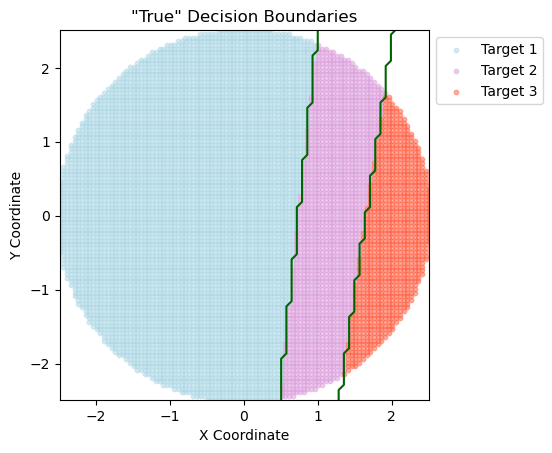

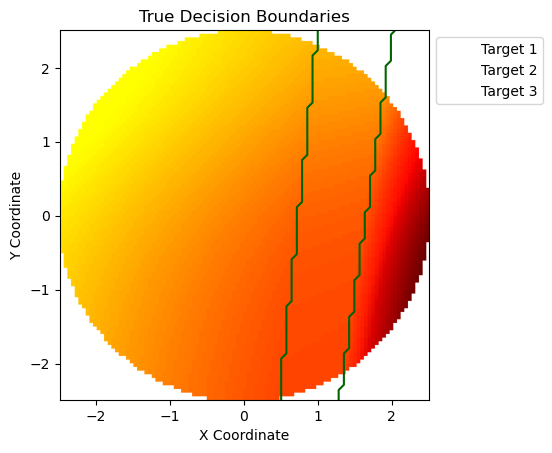

In [24]:
plot_targets_on_simulated_image(train_df_list[9])

plot_targets_on_real_image(train_df_list[9], train_enhanced_images_list[9]) 

In [42]:
print(train_df_list[9])
print(train_boundary_list)

         x     y            Sn            Ba         F  target  target_encoded
0    -2.49 -0.49  3.431102e-07  4.330525e-07  0.442060       1               0
1    -2.49 -0.44  3.420697e-07  4.315406e-07  0.442173       1               0
2    -2.49 -0.39  3.410218e-07  4.300139e-07  0.442291       1               0
3    -2.49 -0.34  3.399667e-07  4.284726e-07  0.442412       1               0
4    -2.49 -0.29  3.389045e-07  4.269172e-07  0.442537       1               0
...    ...   ...           ...           ...       ...     ...             ...
8087  2.51  0.16  5.886133e-07  2.165939e-07  0.731009       3               2
8088  2.51  0.21  5.856752e-07  2.160126e-07  0.730553       3               2
8089  2.51  0.26  5.827312e-07  2.154260e-07  0.730096       3               2
8090  2.51  0.31  5.797820e-07  2.148343e-07  0.729638       3               2
8091  2.51  0.36  5.768278e-07  2.142374e-07  0.729179       3               2

[8092 rows x 7 columns]
[array([0.55, 0.76]), array

In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import numpy as np

# Shape of your images
image_height, image_width, image_channels = 605, 605, 3

# Normalize the images
train_enhanced_images_array_list = np.array(train_images_list) / 255.0
val_enhanced_images_array_list = np.array(val_images_list) / 255.0
test_enhanced_images_array_list = np.array(test_images_list) / 255.0

# Convert boundaries to numpy arrays
train_boundary_array_list = np.array(train_boundary_list)
val_boundary_array_list = np.array(val_boundary_list)
test_boundary_array_list = np.array(test_boundary_list)

# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(image_height, image_width, image_channels)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(2)  # Output layer for the boundary coordinates
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Summary of the model
model.summary()

# Fit the model
history = model.fit(
    train_enhanced_images_array_list, train_boundary_array_list,
    validation_data=(val_enhanced_images_array_list, val_boundary_array_list),
    epochs= 50,  
    batch_size=8 
)

# Evaluate the model on the test data
test_loss, test_mae = model.evaluate(test_enhanced_images_array_list, test_boundary_array_list)

print(f'Test Loss: {test_loss}, Test MAE: {test_mae}')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 603, 603, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 301, 301, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 299, 299, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 149, 149, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 147, 147, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 73, 73, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 682112)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │    43,655,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,748,610 (166.89 MB)

 Trainable params: 43,748,610 (166.89 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - loss: 221.9526 - mae: 6.6769 - val_loss: 0.1211 - val_mae: 0.2824
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 51s 4s/step - loss: 0.2163 - mae: 0.3741 - val_loss: 0.0350 - val_mae: 0.1552
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - loss: 0.0864 - mae: 0.2422 - val_loss: 0.0150 - val_mae: 0.1053
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - loss: 0.0821 - mae: 0.2364 - val_loss: 0.0163 - val_mae: 0.1017
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - loss: 0.1129 - mae: 0.2751 - val_loss: 0.0739 - val_mae: 0.2666
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - loss: 0.0885 - mae: 0.2461 - val_loss: 0.1390 - val_mae: 0.3684
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - loss: 0.0937 - mae: 0.2529 - val_loss: 0.0358 - val_mae: 0.1821
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - loss: 0.0847 - mae: 0.2369 - val_loss: 0.0080 - val_mae: 0.0744
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - loss: 0.0758 - mae

In [40]:

test_true = test_boundary_array_list
test_pred = model.predict(test_enhanced_images_array_list)



2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step


In [31]:
for i in range(50):
    boundary1 = test_pred[i][0]
    boundary2 = test_pred[i][1]
    test_df_list[i]['target_pred'] = test_df_list[i]['F'].apply(lambda x: 1 if x < boundary1 else 2 if boundary1 <= x <= boundary2 else 3)


In [15]:
test_pred 

array([[0.59763217, 0.6937936 ],
       [0.5788701 , 0.67596453],
       [0.60176307, 0.71210283],
       [0.5016269 , 0.5566684 ],
       [0.59728545, 0.692687  ],
       [0.58879226, 0.6878545 ],
       [0.59975487, 0.7006763 ],
       [0.5495714 , 0.52516246],
       [0.5918117 , 0.68638945],
       [0.5938179 , 0.68692315],
       [0.59361446, 0.708872  ],
       [0.58487767, 0.6833718 ],
       [0.58246785, 0.7020559 ],
       [0.5036889 , 0.56142783],
       [0.60062194, 0.6998315 ],
       [0.48387066, 0.5066326 ],
       [0.5853366 , 0.68072265],
       [0.60384387, 0.7032782 ],
       [0.5952972 , 0.70692146],
       [0.5951496 , 0.70732534],
       [0.6009183 , 0.7050871 ],
       [0.5924153 , 0.70143396],
       [0.5836199 , 0.701947  ],
       [0.5315736 , 0.60241395],
       [0.5961016 , 0.69438666],
       [0.6146256 , 0.72562444],
       [0.57933605, 0.7002725 ],
       [0.57134265, 0.65775055],
       [0.5915574 , 0.6898526 ],
       [0.574297  , 0.66513866],
       [0.

In [38]:
np.round(test_pred - test_true,4)

array([[ 0.0332,  0.0484],
       [ 0.1223,  0.0383],
       [-0.0126,  0.0423],
       [ 0.0239,  0.0411],
       [-0.007 ,  0.0278],
       [ 0.075 ,  0.0673],
       [-0.0078,  0.0745],
       [ 0.0276,  0.0334],
       [ 0.0421,  0.0039],
       [ 0.0317,  0.0569],
       [ 0.0082,  0.0145],
       [ 0.0854,  0.029 ],
       [-0.0212,  0.0062],
       [-0.0129,  0.0247],
       [ 0.0912,  0.0579],
       [ 0.0602,  0.0692],
       [ 0.0031,  0.0853],
       [-0.0085,  0.0063],
       [-0.0245,  0.0405],
       [ 0.0051,  0.0302],
       [-0.0159,  0.0382],
       [ 0.0203, -0.0144],
       [-0.0377,  0.0194],
       [ 0.0391,  0.029 ],
       [ 0.0671, -0.0047],
       [-0.0535, -0.0055],
       [-0.0618,  0.026 ],
       [ 0.0652, -0.0042],
       [ 0.0192,  0.0633],
       [ 0.0248,  0.0875],
       [ 0.0657,  0.0444],
       [ 0.039 ,  0.0165],
       [ 0.0548,  0.0118],
       [ 0.0804,  0.053 ],
       [ 0.0052,  0.0303],
       [ 0.1199,  0.05  ],
       [ 0.0512, -0.0249],
 

In [33]:
def plot_combined_targets_on_image(df, img):
    # img_width, img_height = img.size

    # Create a figure and axis
    fig, ax = plt.subplots()

    # Display the image
    ax.imshow(img, extent=[df['x'].min(), df['x'].max(), df['y'].min(), df['y'].max()])

    # Plot points based on target values
    colors = {1: 'lightblue', 2: 'plum', 3: 'tomato'}
    
    # Plot each unique coordinate for each target
    for target in colors.keys():
        target_points = df[df['target'] == target]
        ax.scatter(target_points['x'], target_points['y'], 
                   color=colors[target], 
                   label=f'True Target {target}', 
                   s=10,
                   alpha = 0)

    # Set the axis limits to match the coordinate range
    ax.set_xlim([df['x'].min(), df['x'].max()])
    ax.set_ylim([df['y'].min(), df['y'].max()])

    # Encode the true target labels
    le_true = LabelEncoder()
    df['target_encoded_true'] = le_true.fit_transform(df['target'])

    # Fit logistic regression model for true targets
    X = df[['x', 'y']]
    y_true = df['target_encoded_true']
    model_true = LogisticRegression()
    model_true.fit(X, y_true)

    # Create a mesh to plot the true decision boundaries
    x_min, x_max = df['x'].min() - 1, df['x'].max() + 1
    y_min, y_max = df['y'].min() - 1, df['y'].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=['x', 'y'])
    Z_true = model_true.predict(grid_points)
    Z_true = Z_true.reshape(xx.shape)

    # Plot true decision boundaries
    ax.contour(xx, yy, Z_true, levels=[0.5, 1.5], colors=['darkgreen'], linestyles=['-'], label = 'True boundaries')
    

    # Encode the predicted target labels
    le_pred = LabelEncoder()
    df['target_encoded_pred'] = le_pred.fit_transform(df['target_pred'])

    # Fit logistic regression model for predicted targets
    y_pred = df['target_encoded_pred']
    model_pred = LogisticRegression()
    model_pred.fit(X, y_pred)

    # Create a mesh to plot the predicted decision boundaries
    Z_pred = model_pred.predict(grid_points)
    Z_pred = Z_pred.reshape(xx.shape)

    # Plot predicted decision boundaries
    ax.contour(xx, yy, Z_pred, levels=[0.5, 1.5], colors=['purple'], linestyles=['--'], label = 'Predict boundaries')

    # Add custom legend entries for boundaries
    handles, labels = ax.get_legend_handles_labels()
    handles.append(plt.Line2D([0], [0], color='darkgreen', linestyle='-', linewidth=2))
    labels.append('True Boundaries')
    handles.append(plt.Line2D([0], [0], color='purple', linestyle='--', linewidth=2))
    labels.append('Predicted Boundaries')
    
    ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(1, 1))
    
    
    # Show the plot
    plt.show()

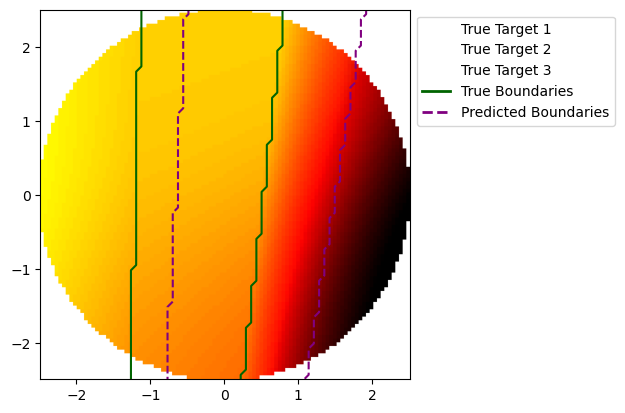

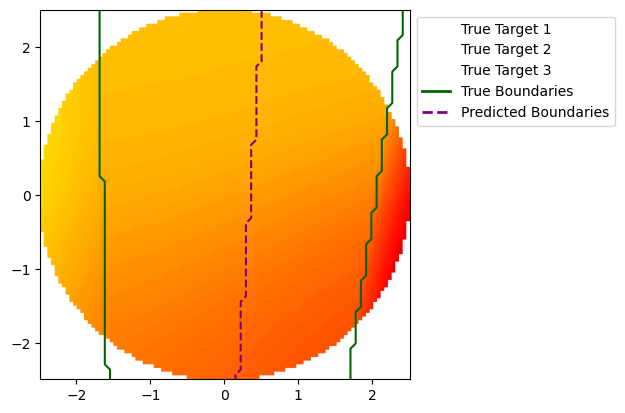

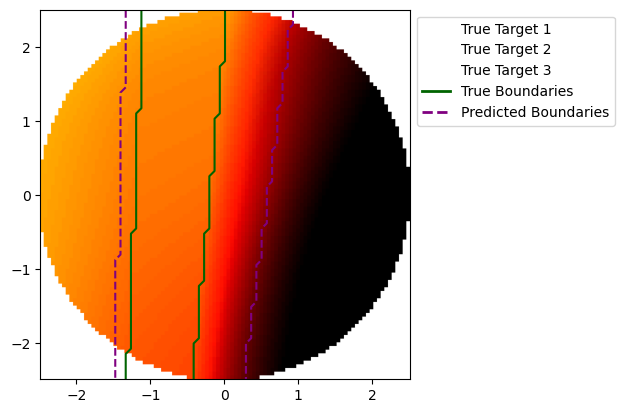

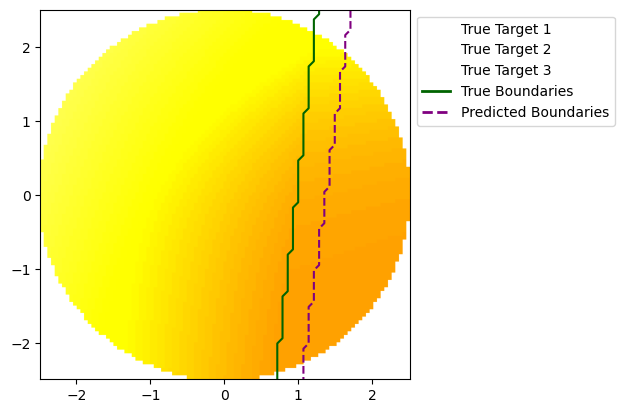

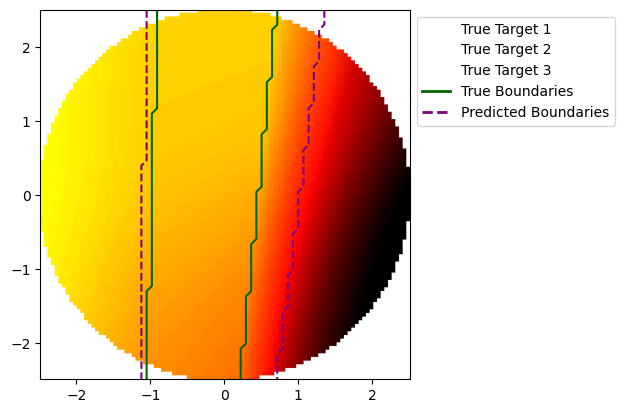

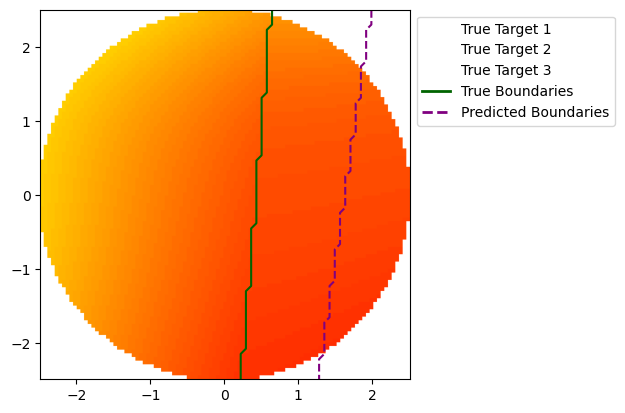

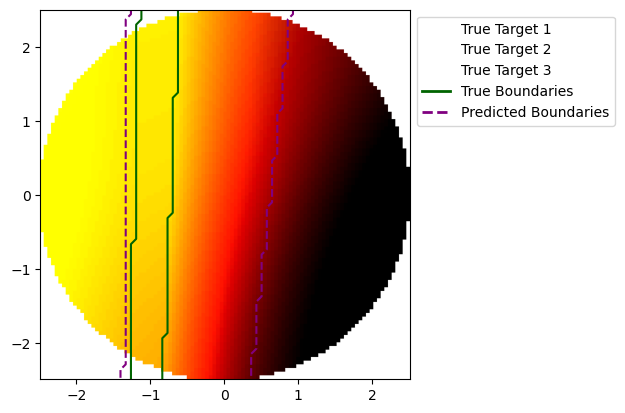

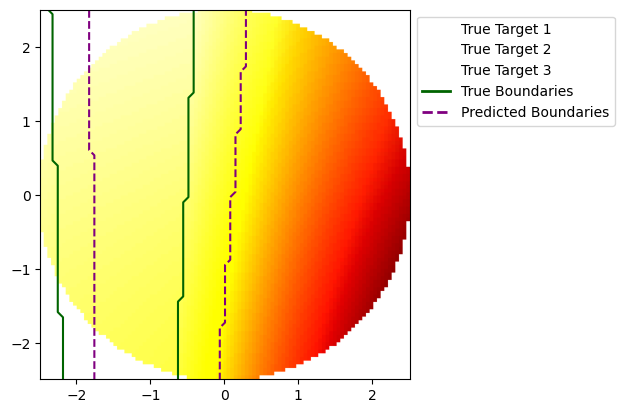

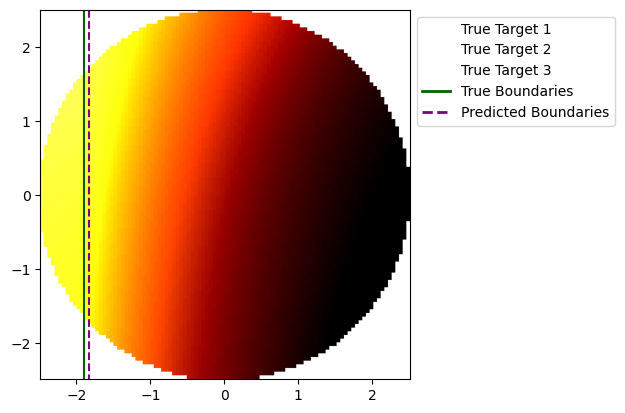

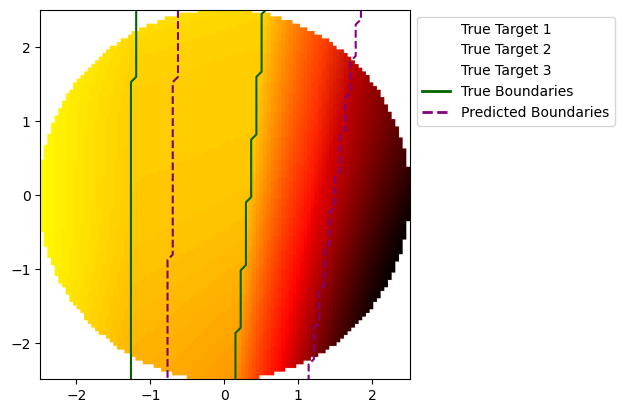

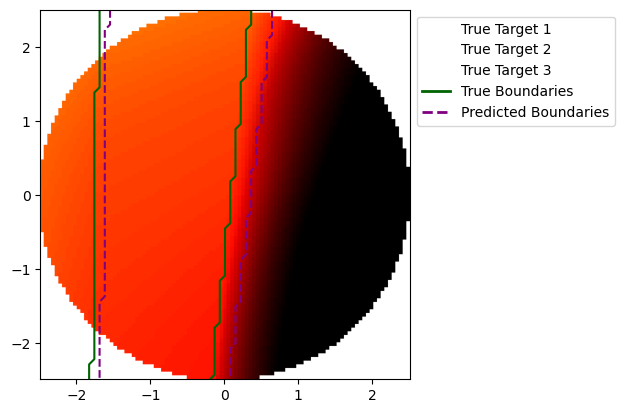

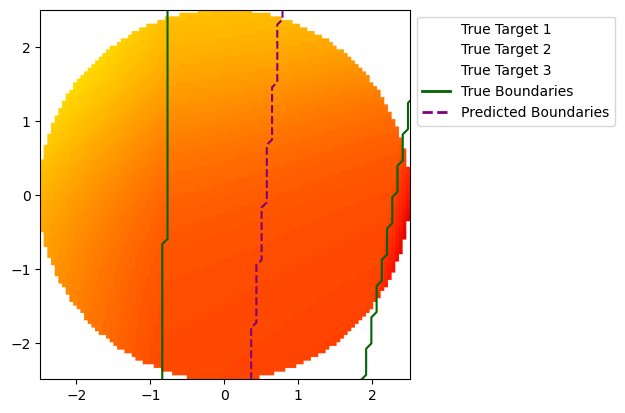

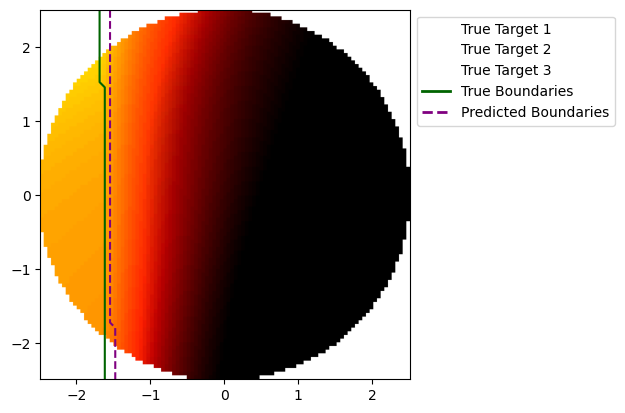

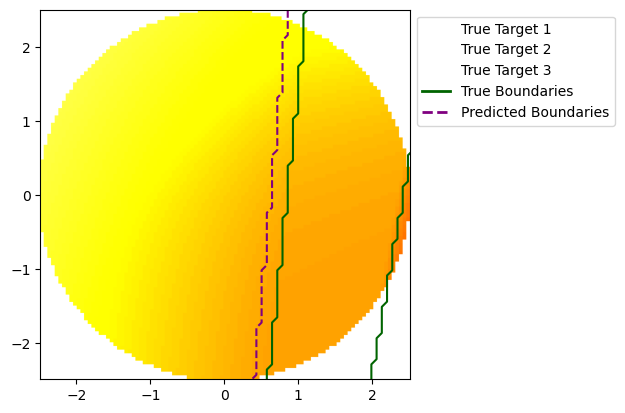

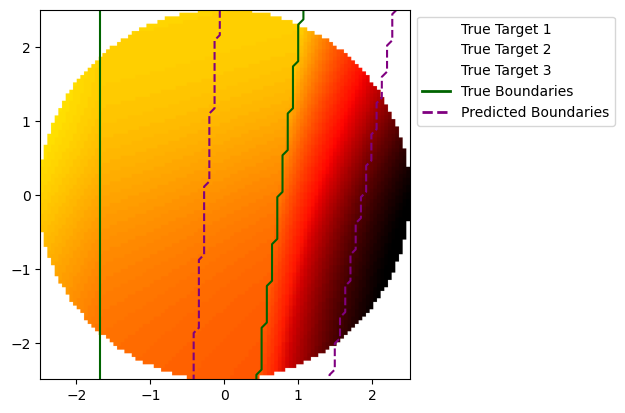

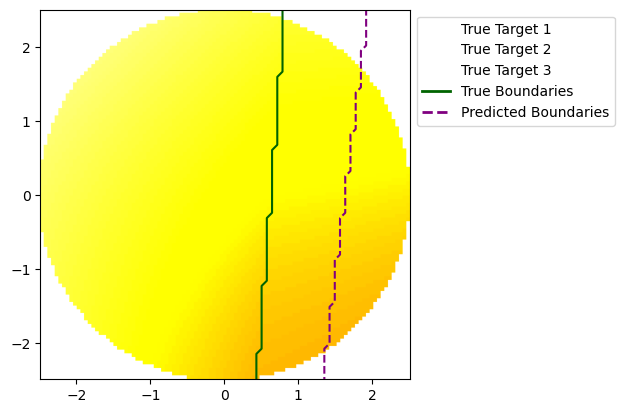

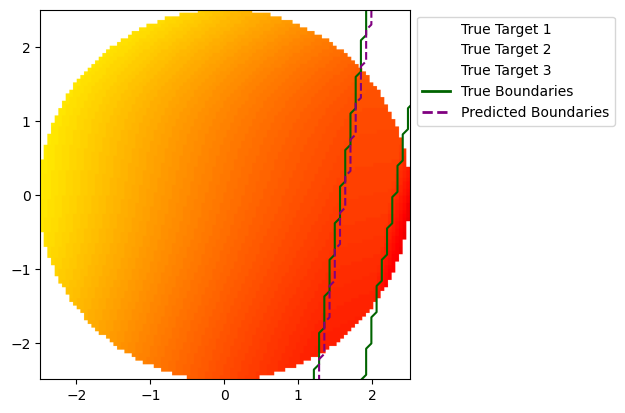

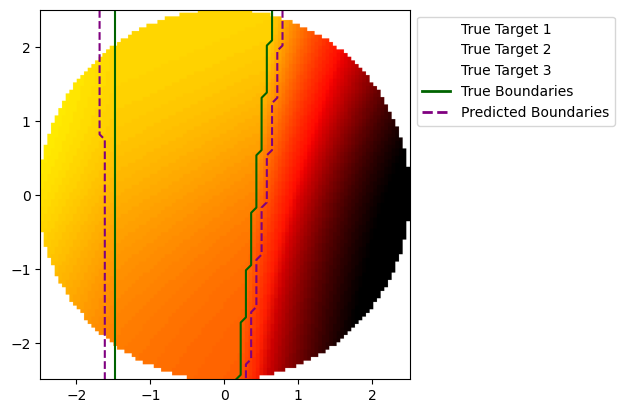

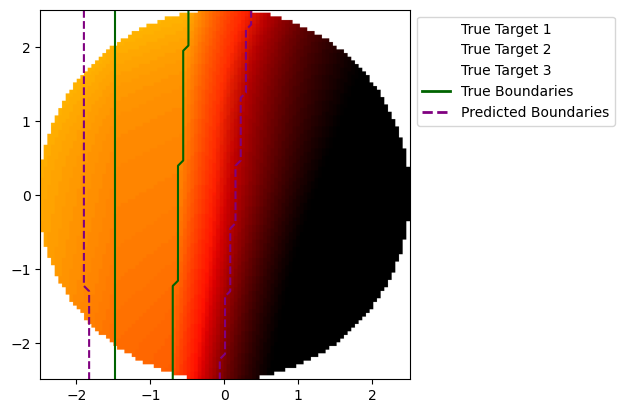

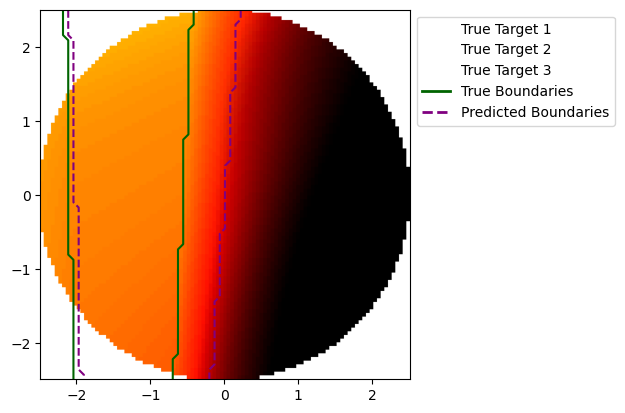

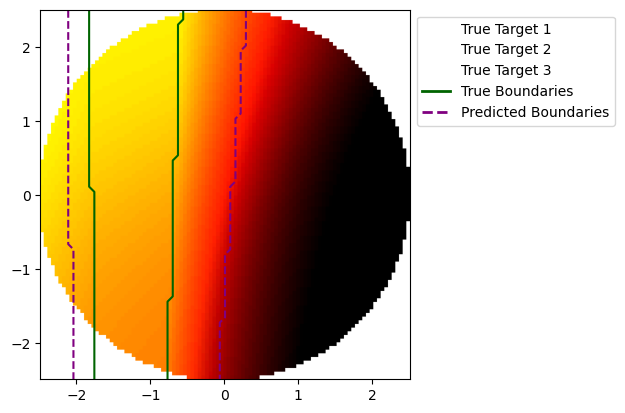

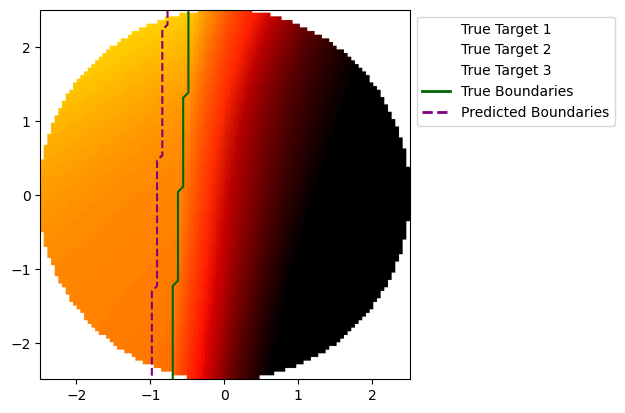

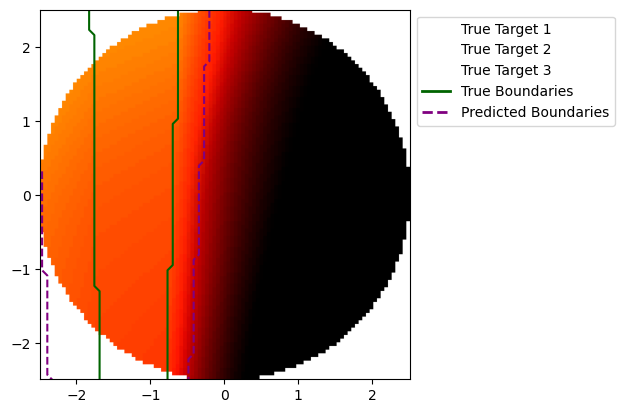

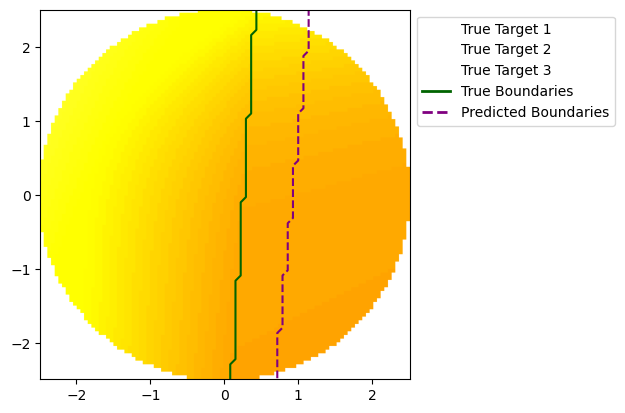

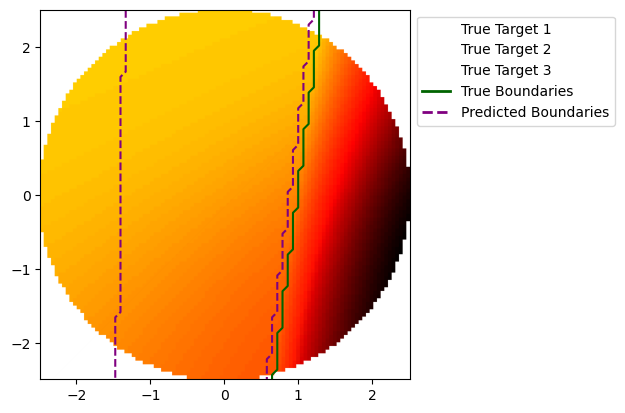

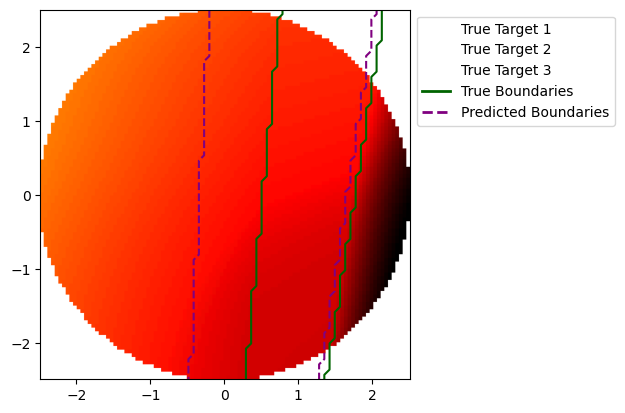

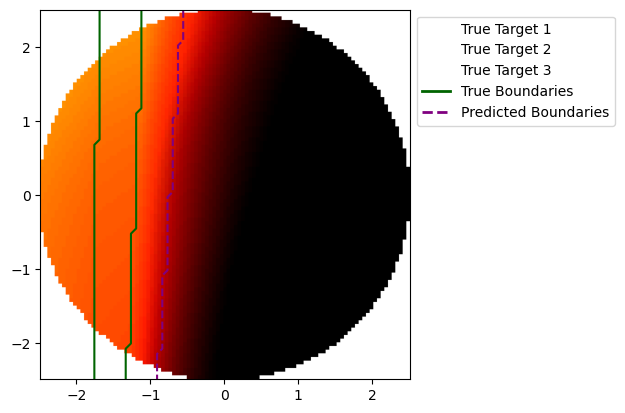

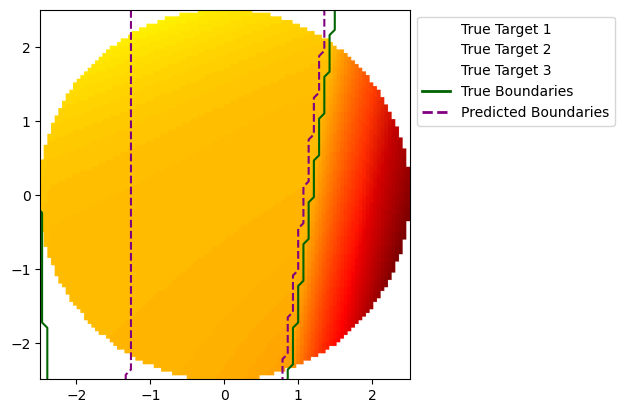

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 0

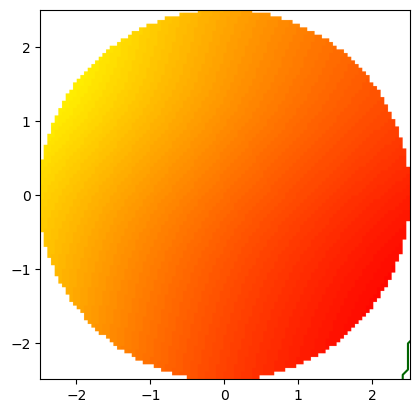

In [34]:
for i in range(50):
    plot_combined_targets_on_image(test_df_list[i], test_enhanced_images_list[i]) 